In [1]:
# Connecting google colab to My Drive and importing all the libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#uploading dataset
file_path = '/content/drive/My Drive/helmet detection'

In [3]:
# Data augmentation for the dataset that will be used during training
training_datagenerator = ImageDataGenerator(rescale = 1./255, horizontal_flip = True,
                                            #vertical_flip = True,
                                            shear_range = 0.1,
                                            zoom_range = 0.15,
                                            width_shift_range = 0.1,
                                            brightness_range=(0.7, 1.3),                                          #height_shift_range = 0.2,
                                            validation_split = 0.1
                                            )
validation_datagenerator = ImageDataGenerator ( rescale = 1./255)

In [4]:
# Loading and resizing the data and dividing it into training and validation set
train = training_datagenerator.flow_from_directory("/content/drive/My Drive/helmet detection/train",
                                                  target_size = (128, 128), color_mode = 'rgb', class_mode = 'binary',
                                                  batch_size = 32,shuffle=True)

validation = validation_datagenerator.flow_from_directory("/content/drive/My Drive/helmet detection/valid",
                                                  target_size = (128, 128), color_mode = 'rgb', class_mode = 'binary',
                                                  batch_size = 32, shuffle=False)
print(train.class_indices)

Found 3640 images belonging to 2 classes.
Found 2459 images belonging to 2 classes.
{'with helmet': 0, 'without helmet': 1}


In [5]:
# Compute Class Weights ---
labels = train.classes  # 0/1 labels from training generator
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.6957186544342507), 1: np.float64(1.77734375)}


In [6]:
import tensorflow as tf
from tensorflow.keras import backend as K

def focal_loss(alpha=0.35, gamma=2.0):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = K.binary_crossentropy(y_true, y_pred)
        y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow((1 - p_t), gamma)
        return K.mean(alpha_factor * modulating_factor * bce, axis=-1)
    return focal_loss_fixed

In [7]:
from tensorflow.keras import layers, regularizers, models
# Initializing convolutional neural network
cnn = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,441 (1.17 MB)

 Trainable params: 304,545 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=7, restore_best_weights=True, verbose=1)

plateau = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1)

In [10]:
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall, AUC

batch_size = 32
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(alpha=0.25, gamma=2.0),
    metrics=[
        Precision(name='prec'),
        Recall(name='rec'),
        AUC(name='auc'),
        'accuracy'
    ]
)

history = cnn.fit(
    train,
    validation_data=validation,
    epochs=20,
    callbacks=[early_stop, plateau],
    class_weight=class_weights
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1648s 14s/step - accuracy: 0.6892 - auc: 0.6811 - loss: 0.1067 - prec: 0.4570 - rec: 0.3758 - val_accuracy: 0.3115 - val_auc: 0.5140 - val_loss: 0.1963 - val_prec: 0.3115 - val_rec: 1.0000 - learning_rate: 0.0010
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 600s 5s/step - accuracy: 0.7923 - auc: 0.8295 - loss: 0.0682 - prec: 0.6791 - rec: 0.4900 - val_accuracy: 0.3188 - val_auc: 0.4736 - val_loss: 0.2744 - val_prec: 0.3129 - val_rec: 0.9922 - learning_rate: 0.0010
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8150 - auc: 0.8465 - loss: 0.0658 - prec: 0.7238 - rec: 0.5482
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
114/114 ━━━━━━━━━━━━━━━━━━━━ 593s 5s/step - accuracy: 0.8151 - auc: 0.8467 - loss: 0.0657 - prec: 0.7240 - rec: 0.5485 - val_accuracy: 0.3440 - val_auc: 0.4361 - val_loss: 0.2233 - val_prec: 0.3020 - val_rec: 0.8433 - learning_rate: 0.0010
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 627s 6s/step

<Axes: >

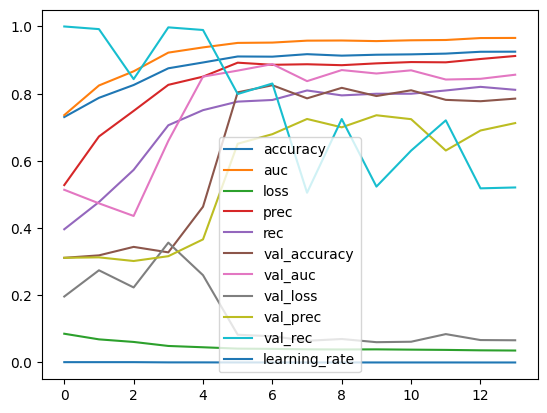

In [11]:
import pandas as pd
pd.DataFrame(history.history).plot()


In [12]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score,precision_recall_curve
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [13]:
from sklearn.metrics import f1_score,precision_recall_curve
# Reset the validation generator to start from the beginning
validation.reset()

# Get predicted probabilities
pred_probs = cnn.predict(validation, verbose=0).ravel()

In [14]:
true_classes = validation.classes  # actual labels
prec, rec, thr = precision_recall_curve(true_classes, pred_probs)   # assumes y_true==1 means "fire"
f1s = 2*prec*rec/(prec+rec + 1e-9)
best_idx = f1s.argmax()
best_thr = thr[best_idx]
print("Best F1:", f1s[best_idx], "at threshold:", best_thr)

# Convert probabilities to binary class labels (0 or 1)
pred_classes = (pred_probs >= best_thr).astype(int)

class_labels = list(validation.class_indices.keys())  # ['class0', 'class1']

Best F1: 0.7481005255136546 at threshold: 0.49828565


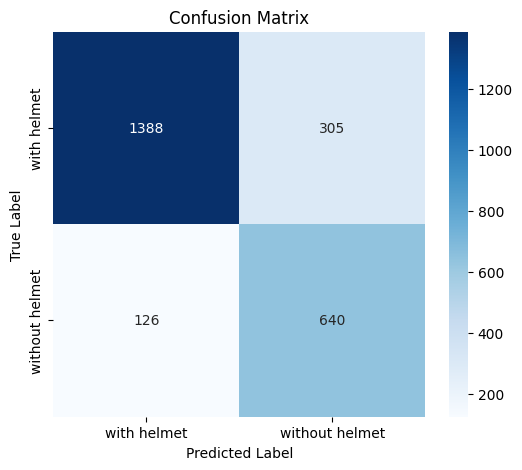

In [15]:
cm = confusion_matrix(true_classes, pred_classes)

# Plot it using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [16]:
print("Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

Classification Report:
                precision    recall  f1-score   support

   with helmet       0.92      0.82      0.87      1693
without helmet       0.68      0.84      0.75       766

      accuracy                           0.82      2459
     macro avg       0.80      0.83      0.81      2459
  weighted avg       0.84      0.82      0.83      2459



In [17]:
test_datagen = ImageDataGenerator(rescale=1./255)

test = test_datagen.flow_from_directory(
    "/content/drive/My Drive/helmet detection/test",
    target_size=(128,128),
    color_mode='rgb',
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

results = cnn.evaluate(test, verbose=0)
print("Results:", results)

# or unpack properly
test_loss, test_acc, test_auc, test_prec, test_rec = cnn.evaluate(test)
print( test_acc)
print( test_auc)
#print(st_prec)
print( test_rec)


Found 253 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Results: [0.03782601282000542, 0.9454545378684998, 0.8595041036605835, 0.9612133502960205, 0.9090909361839294]
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9487 - auc: 0.5391 - loss: 0.0363 - prec: 0.5043 - rec: 0.4987
0.9454545378684998
0.8595041036605835
0.9090909361839294


In [19]:
# Optional: put models in a folder
import os
SAVE_DIR = "/content/drive/My Drive/models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save BOTH formats (safe for Keras 3 + easy reuse)
h5_path    = os.path.join(SAVE_DIR, "helmetdetect_CNN_Model.h5")
keras_path = os.path.join(SAVE_DIR, "helmetdetect_CNN_Model.keras")

# Tip: exclude optimizer to avoid custom-loss deserialization issues later
cnn.save(h5_path, include_optimizer=False)
cnn.save(keras_path, include_optimizer=False)

print("Saved:", h5_path)
print("Saved:", keras_path)

Saved: /content/drive/My Drive/models/helmetdetect_CNN_Model.h5
Saved: /content/drive/My Drive/models/helmetdetect_CNN_Model.keras
